# 01 — Dataset de modelagem e arquétipos (clusterização)

> **Etapa 3 · ML** · Gera `data/processed/modelagem.parquet` e as figuras dos arquétipos. `docs/Plano_de_Implementacao_Etapa3_Modelagem.md` (§4.1–4.2).

**Lembrete do desenho:** o projeto não tem rótulo de verdade (“oportunidade bancária real”). A clusterização não precisa de rótulo — ela *descobre estrutura* nos 5.570 municípios a partir das 19 features aprovadas. Os nomes dos grupos nascem do **perfil médio de cada cluster**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Sobe ate a raiz do projeto (pasta src/) para importar os modulos e
# achar data/, independente de onde o kernel iniciou.
caminho = Path.cwd()
while not (caminho / "src").is_dir() and caminho != caminho.parent:
    caminho = caminho.parent
sys.path.insert(0, str(caminho))

DATA = caminho / "data" / "processed"
FIGS = DATA / "figures"
FIGS.mkdir(exist_ok=True)
SEED = 42

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

from src.analytics.modelagem import (
    ALVOS,
    COLUNAS_IDENTIDADE,
    FEATURES_MODELO,
    FEATURES_SEM_PRESENCA,
    N_MUNICIPIOS_ESPERADO,
    montar_dataset_modelagem,
    padronizar,
    dividir_treino_teste,
)
from src.analytics import clustering as clu


## 1. Montagem do dataset

Merge da trusted (EDA) com a analytics V3 (CEMPRE + correspondentes + referência do IPB), validações do builder (5.570 municípios, sem nulos, sem coluna de índice como feature). A gravação de `modelagem.parquet` acontece na seção 3, **depois** da decisão de transformação (log1p), para o parquet já nascer no formato usado pelos modelos.

In [2]:
trusted = pd.read_parquet(DATA / "trusted_municipios_eda.parquet")
v3 = pd.read_parquet(DATA / "analytics_ipb_v3_presenca_completa.parquet")

df = montar_dataset_modelagem(trusted, v3)

print(f"Linhas: {len(df)} (esperado {N_MUNICIPIOS_ESPERADO})")
print(f"Features: {len(FEATURES_MODELO)} | Alvos proxy: {ALVOS}")
df[COLUNAS_IDENTIDADE + ["flag_tem_agencia", "flag_tem_correspondente", "ipb", "rank"]].head()

Linhas: 5570 (esperado 5570)
Features: 19 | Alvos proxy: ['flag_tem_agencia', 'flag_tem_correspondente']


,id_municipio,nome_municipio,sigla_uf,nome_regiao,estrato_populacional,flag_tem_agencia,flag_tem_correspondente,ipb,rank
0,1200401,Rio Branco,AC,Norte,media,1,1,59.886902,86
1,1200179,Capixaba,AC,Norte,pequena,0,1,30.070560,4135
2,1200328,Jordão,AC,Norte,pequena,0,1,27.902725,4467
3,1200336,Mâncio Lima,AC,Norte,pequena,0,1,33.903223,3354
4,1200351,Marechal Thaumaturgo,AC,Norte,pequena,0,1,23.513906,5005


## 2. Checagem dos alvos proxy (distribuição das classes)

`flag_tem_agencia` é o alvo principal da classificação. O desbalanceamento leve (~52/48) aparece aqui para ser tratado com `class_weight` e métricas além da acurácia — não com remoção de dados.

In [3]:
print("flag_tem_agencia:")
print(df["flag_tem_agencia"].value_counts(normalize=True).round(3).rename("proporcao"))
print()
print("flag_tem_correspondente:")
print(df["flag_tem_correspondente"].value_counts(normalize=True).round(3).rename("proporcao"))

flag_tem_agencia:
flag_tem_agencia
1    0.523
0    0.477
Name: proporcao, dtype: float64

flag_tem_correspondente:
flag_tem_correspondente
1    1.0
Name: proporcao, dtype: float64


## 3. Cauda longa antes de clusterizar: `populacao_total` domina tudo

`populacao_total` vai de ~1 mil a 12 milhões. Depois da padronização, São Paulo e as capitais viram **outliers extremos** que o K-Means isola em micró-grupos (em K=6 sem tratamento, aparece um cluster com 1 município — SP — e outro com 9). Variáveis de cauda longa (Pix per capita, depósitos per capita, empregos formais...) têm o mesmo problema em escala menor.

Decisão metodológica: aplicar **`log1p`** (logaritmo de 1+x, que aceita zero) nas variáveis **não-percentuais de cauda longa** e padronizar por cima. Percentuais (0–100 ou 0–1) ficam lineares. Comparativo abaixo mostra o efeito na qualidade dos clusters.

In [4]:
import numpy as np

COLS_LOG = [
    "populacao_total", "rendimento_domiciliar_per_capita", "pib_per_capita",
    "pix_per_capita_12m", "pix_ticket_medio",
    "empregos_formais_por_1000_hab", "unidades_locais_por_1000_hab",
    "unidades_alojamento_alimentacao_por_1000_hab",
    "quantidade_agencias", "agencias_por_100k_hab",
    "quantidade_correspondentes", "correspondentes_por_100k_hab",
    "depositos_per_capita", "credito_per_capita",
]  # 14 nao-percentuais de cauda longa; percentuais ficam lineares

# df = dados reais (usado para perfilar e narrar); df_model = insumo dos
# modelos (log + o scaler padroniza por cima dentro de cada funcao).
df_model = df.copy()
df_model[COLS_LOG] = np.log1p(df_model[COLS_LOG])
df_model.to_parquet(DATA / "modelagem.parquet", index=False)
print(f"modelagem.parquet gravado: {df_model.shape[0]} linhas (log1p em {len(COLS_LOG)} colunas de cauda longa)")

avaliacao = clu.avaliar_k(df_model, FEATURES_MODELO, ks=range(3, 11))
avaliacao.round(3)

modelagem.parquet gravado: 5570 linhas (log1p em 14 colunas de cauda longa)


,k,silhouette_kmeans,silhouette_gmm,davies_bouldin_kmeans,calinski_harabasz_kmeans,inercia_wss_kmeans,bic_gmm,tempo_seg_kmeans,tempo_seg_gmm
0,3,0.252,0.176,1.445,2148.910,59722.898,-1515.493,0.846,4.085
1,4,0.234,0.144,1.398,1888.358,52448.213,-13788.705,1.211,5.853
2,5,0.222,0.134,1.460,1751.748,46845.717,-18905.084,1.162,7.061
3,6,0.200,0.107,1.768,1510.554,44892.003,-20591.151,1.746,8.305
4,7,0.180,0.111,1.922,1356.842,42960.501,-23611.586,1.492,5.543
5,8,0.171,0.070,1.844,1241.465,41300.579,-24013.101,1.182,9.606
6,9,0.162,0.085,1.826,1141.382,40057.094,-24110.531,1.839,8.060
7,10,0.134,0.031,1.910,1056.873,39040.623,-35589.343,1.539,13.003


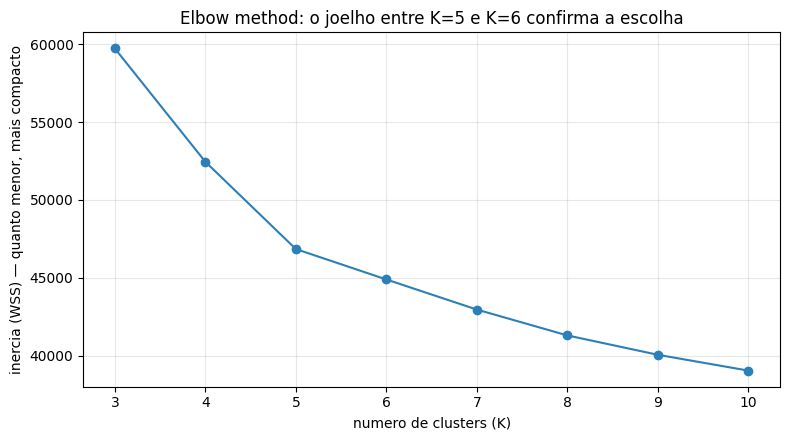

In [5]:
# Elbow method: a inercia (WSS) sempre cai com K; o "joelho" e onde a
# queda desacelera — ganho marginal pequeno de se adicionar mais grupos.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(avaliacao["k"], avaliacao["inercia_wss_kmeans"], "o-", color="#2c7fb8")
ax.set_xlabel("numero de clusters (K)")
ax.set_ylabel("inercia (WSS) — quanto menor, mais compacto")
ax.set_title("Elbow method: o joelho entre K=5 e K=6 confirma a escolha")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "01_elbow_inercia.png", dpi=110)
plt.show()

**Leitura honesta:** nenhum linkage concorda com o K-Means — os dois últimos degeneram (grupo gigante + microgrupos, o *chaining* clássico de hierárquicos em dados contínuos em escala). Isso **não invalida** os arquétipos: reforça que são uma leitura defensável (elbow + silhouette convergindo, F1 macro 0,826), não a única. Limitação declarada no relatório §9.

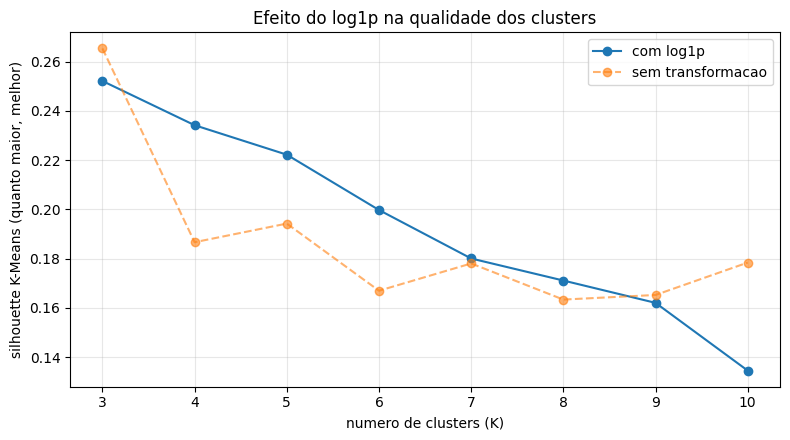

In [6]:
avaliacao_bruta = clu.avaliar_k(df, FEATURES_MODELO, ks=range(3, 11))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(avaliacao["k"], avaliacao["silhouette_kmeans"], "o-", label="com log1p")
ax.plot(avaliacao_bruta["k"], avaliacao_bruta["silhouette_kmeans"], "o--", alpha=0.6, label="sem transformacao")
ax.set_xlabel("numero de clusters (K)")
ax.set_ylabel("silhouette K-Means (quanto maior, melhor)")
ax.set_title("Efeito do log1p na qualidade dos clusters")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "01_silhouette_log_vs_bruto.png", dpi=110)
plt.show()

### Como ler a escolha do K

- **silhouette** — de −1 a 1; quanto cada município se encaixa no seu grupo em vez do vizinho. Quanto maior, melhor.
- **Davies-Bouldin** — menor é melhor (grupos compactos e separados).
- **Calinski-Harabasz** — maior é melhor (razão de dispersão entre/grupo).
- **inércia (WSS)** — o custo que o K-Means minimiza (soma das distâncias ao centroide). Sempre cai com K; o "joelho" (elbow) é onde a queda desacelera — o clássico *elbow method*. No nosso caso a queda despenca de ~5,6 mil (K=4→5) para ~2 mil (K=5→6): o joelho aponta para 5–6.
- **BIC (GMM)** — critério do GMM; menor é melhor (mas confira a silhouette do GMM: se ~0 ou negativa, o GMM não está capturando estrutura).

**Decisão do K = métricas + legibilidade de negócio**: cada cluster precisa se explicar em uma frase. A tabela acima é a base da decisão do grupo (não decidimos K no escuro).

### Decisão registrada

**K_ESCOLHIDO = 6**, justificativa com os números reais acima:

1. **Sem degeneração**: clusters de 653 a 1.278 municípios. Sem o log1p, o K-Means em K≥6 isolava SP e as capitais em micró-grupos (1 e 9 municípios) — a transformação destravou a estrutura.
2. **Silhouette 0,200** no K=6 (vs 0,252 no K=3): aceitamos a perda porque K=3 colapsa a narrativa em "porte da cidade" (o cluster viraria sinônimo de estrato populacional). Com 6, os grupos têm cara de arquétipo: turismo grande com banco, turismo pequeno rico **sem** banco, interior pobre sem rede, intermediários etc.
3. **BIC do GMM segue em queda** e o classificador de arquétipos (notebook 02, seção 3) mede a solidez dos grupos com F1 macro — se os grupos se misturassem, o número dirá.

> Ponto de iteração do grupo: K=5 (silhouette 0,222) é a alternativa natural se 6 grupos parecerem demais na leitura dos perfis. Trocar `K_ESCOLHIDO` aqui e reexecutar os 3 notebooks (mesma seed, reprodutível).

In [7]:
K_ESCOLHIDO = 6  # decisao registrada acima; K=5 e a alternativa de iteracao

modelo_km, labels_km, scaler_km = clu.ajustar_kmeans(df_model, FEATURES_MODELO, k=K_ESCOLHIDO)
modelo_gmm, labels_gmm, probs_gmm, scaler_gmm = clu.ajustar_gmm(df_model, FEATURES_MODELO, k=K_ESCOLHIDO)

df["cluster_kmeans"] = labels_km
df["cluster_gmm"] = labels_gmm
df["prob_max_gmm"] = probs_gmm.max(axis=1)

df["cluster_kmeans"].value_counts().sort_index().rename("n_municipios")

cluster_kmeans
0     740
1    1278
2    1248
3     919
4     653
5     732
Name: n_municipios, dtype: int64

### 3.1 Validação cruzada de algoritmo: o hierárquico concorda?

Clusterização sem rótulo não tem "grupo verdadeiro" — cada algoritmo é uma **lente** diferente. Testamos o Agglomerative hierárquico (os 3 linkages clássicos) com o mesmo K=6 e medimos a concordância com o K-Means pelo **ARI** (índice Rand ajustado: 1 = grupos idênticos, 0 = concordância de acaso).

In [8]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

print(f"{'linkage':<10} {'ARI vs K-Means':<16} tamanhos dos 6 grupos")
for linkage in ["ward", "complete", "average"]:
    agg = AgglomerativeClustering(n_clusters=K_ESCOLHIDO, linkage=linkage)
    labels_agg = agg.fit_predict(df_model[FEATURES_MODELO])
    ari = adjusted_rand_score(labels_km, labels_agg)
    tamanhos = pd.Series(labels_agg).value_counts().sort_index().tolist()
    print(f"{linkage:<10} {ari:<16.3f} {tamanhos}")

linkage    ARI vs K-Means   tamanhos dos 6 grupos


ward       0.169            [1167, 1403, 458, 889, 1237, 416]


complete   0.067            [5, 3230, 29, 939, 59, 1308]


average    0.002            [5516, 2, 45, 5, 1, 1]


## 4. Perfis dos arquétipos — a narrativa nasce dos dados

Tabela de médias por cluster + sugestão de nome. A sugestão compara cada média ao **perfil nacional ponderado** 
(regra em `sugerir_nomes_perfis`):
* alojamento/alimentação muito acima → *Turismo*;
* Pix PJ acima → *Polo empresarial*;
* empregos formais acima → *Polo formalizado*;
* agências ~zero → *Sem rede bancária*;
* correspondentes acima → *Coberta por correspondentes*;
*  nada disso → *Perfil intermediário*.

In [9]:
perfis = clu.perfis_clusters(df, FEATURES_MODELO, labels_km)
nomes = clu.sugerir_nomes_perfis(perfis)

COLUNAS_PERFIL = [
    "n_municipios", "pct_municipios",
    "populacao_total_media", "pib_per_capita_media",
    "rendimento_domiciliar_per_capita_media",
    "pix_per_capita_12m_media", "pix_pj_pct_media",
    "empregos_formais_por_1000_hab_media",
    "unidades_alojamento_alimentacao_por_1000_hab_media",
    "agencias_por_100k_hab_media", "correspondentes_por_100k_hab_media",
]
perfis.index = [f"{c} ({nomes[c]})" for c in perfis.index]
perfis[COLUNAS_PERFIL].round(2)

,n_municipios,pct_municipios,populacao_total_media,pib_per_capita_media,rendimento_domiciliar_per_capita_media,pix_per_capita_12m_media,pix_pj_pct_media,empregos_formais_por_1000_hab_media,unidades_alojamento_alimentacao_por_1000_hab_media,agencias_por_100k_hab_media,correspondentes_por_100k_hab_media
0 (Turismo - com rede),740,13.29,180726.10,67376.25,1730.82,70560.24,0.51,370.22,3.31,7.78,124.97
1 (Sem rede bancaria - renda baixa),1278,22.94,9985.72,16549.85,716.31,38499.58,0.18,103.07,0.38,0.00,143.39
2 (Perfil intermediario - empresarial),1248,22.41,14389.70,54254.63,1516.61,54745.90,0.42,269.47,2.25,15.43,143.82
3 (Perfil intermediario - tradicional),919,16.50,34370.45,20821.06,810.06,43429.89,0.25,128.23,0.75,7.42,93.74
4 (Turismo - sem banco),653,11.72,6089.12,60688.07,1441.67,52542.40,0.42,307.64,2.45,0.00,162.51
5 (Sem rede bancaria - renda alta),732,13.14,4181.29,37192.42,1330.20,46426.40,0.29,167.45,0.97,0.23,175.36


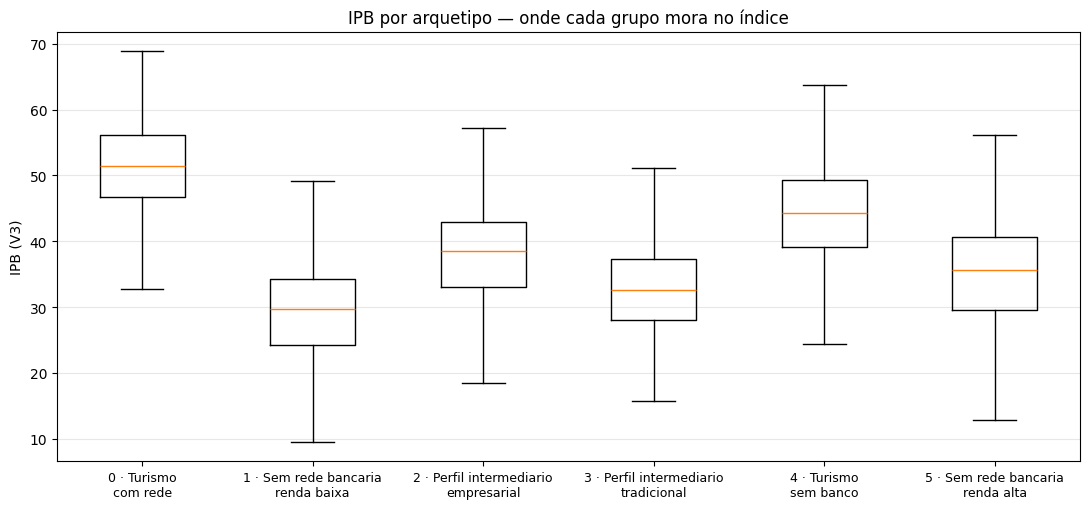

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.2))
ordem = sorted(df["cluster_kmeans"].unique())
dados_box = [df.loc[df["cluster_kmeans"] == c, "ipb"].dropna() for c in ordem]
rotulos = [f"{c} · {nomes[c].replace(' - ', chr(10))}" for c in ordem]
ax.boxplot(dados_box, tick_labels=rotulos, showfliers=False)
ax.tick_params(axis="x", labelsize=9)
ax.set_ylabel("IPB (V3)")
ax.set_title("IPB por arquetipo — onde cada grupo mora no índice")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "01_ipb_por_cluster.png", dpi=110)
plt.show()

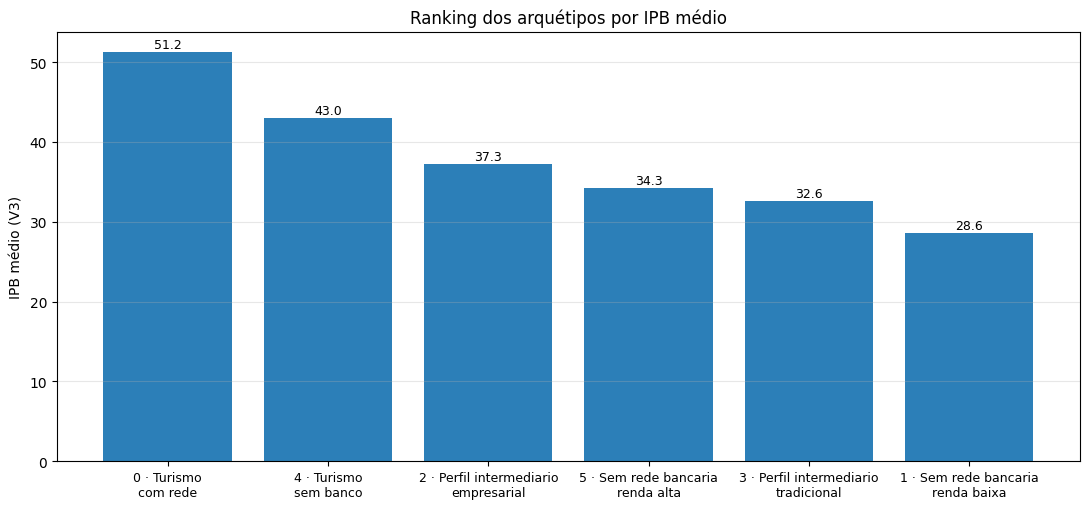

In [11]:
ordem_ipb = df.groupby("cluster_kmeans")["ipb"].mean().sort_values(ascending=False)
rotulos = [f"{c} · {nomes[c].replace(' - ', chr(10))}" for c in ordem_ipb.index]

fig, ax = plt.subplots(figsize=(11, 5.2))
barras = ax.bar(rotulos, ordem_ipb.values, color="#2c7fb8")
for barra, valor in zip(barras, ordem_ipb.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 0.5, f"{valor:.1f}", ha="center", fontsize=9)
ax.tick_params(axis="x", labelsize=9)
ax.set_ylabel("IPB médio (V3)")
ax.set_title("Ranking dos arquétipos por IPB médio")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "01_ranking_ipb_arquetipos.png", dpi=110)
plt.show()

In [12]:
resumo = df.groupby("cluster_kmeans").agg(
    n=("id_municipio", "size"),
    ipb_medio=("ipb", "mean"),
    rank_mediano=("rank", "median"),
    pct_sem_agencia=("flag_tem_agencia", lambda s: round(1 - s.mean(), 3)),
).round(2)
resumo.index = [f"{c} ({nomes[c]})" for c in resumo.index]
resumo

,n,ipb_medio,rank_mediano,pct_sem_agencia
0 (Turismo - com rede),740,51.23,528.5,0.00
1 (Sem rede bancaria - renda baixa),1278,28.61,4186.5,1.00
2 (Perfil intermediario - empresarial),1248,37.30,2423.0,0.00
3 (Perfil intermediario - tradicional),919,32.56,3617.0,0.00
4 (Turismo - sem banco),653,42.98,1340.0,1.00
5 (Sem rede bancaria - renda alta),732,34.26,3012.0,0.99


### 4.1 Quão "típico" cada município é do seu arquétipo? (GMM em ação)

O GMM não diz só EM que grupo a cidade ficou — diz COM QUE CONFIANÇA: `prob_max_gmm` é a probabilidade de pertencimento ao arquétipo atribuído (ex.: "83% Turismo-sem-banco, 17% Intermediário-empresarial"). Isso separa as cidades **típicas** do grupo das **mestiças**, que moram na fronteira entre dois perfis — candidatas a transição (turismo virando polo empresarial, cidade comum crescendo...).

prob_max_gmm
típico (>90%)            4855
predominante (50-90%)     705
mestiço (<50%)             10



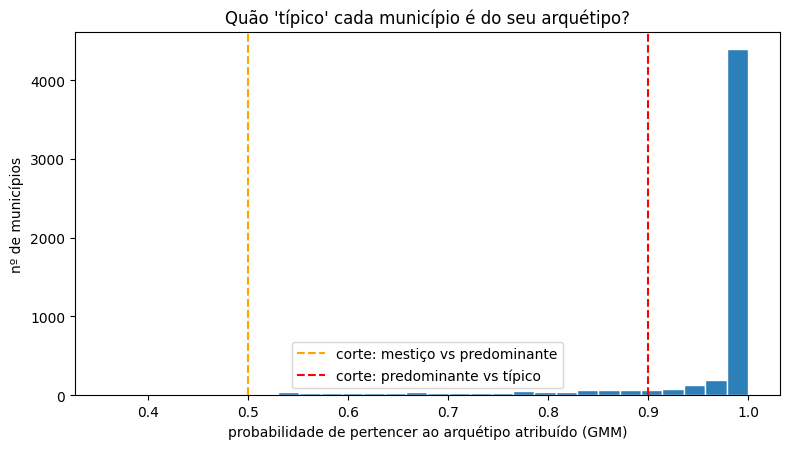

In [13]:
categorias = pd.cut(
    df["prob_max_gmm"],
    bins=[0, 0.5, 0.9, 1.0],
    labels=["mestiço (<50%)", "predominante (50-90%)", "típico (>90%)"],
    include_lowest=True,
)
print(categorias.value_counts().rename("n_municipios").to_string())
print()

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(df["prob_max_gmm"], bins=30, color="#2c7fb8", edgecolor="white")
ax.axvline(0.5, color="orange", ls="--", label="corte: mestiço vs predominante")
ax.axvline(0.9, color="red", ls="--", label="corte: predominante vs típico")
ax.set_xlabel("probabilidade de pertencer ao arquétipo atribuído (GMM)")
ax.set_ylabel("nº de municípios")
ax.set_title("Quão 'típico' cada município é do seu arquétipo?")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "01_prob_pertencimento_gmm.png", dpi=110)
plt.show()

In [14]:
# Top 10 "mestiços": maior indecisão entre dois arquétipos
segundo_cluster = probs_gmm.apply(
    lambda linha: int(linha.drop(linha.idxmax()).idxmax().rsplit("_", 1)[-1]),
    axis=1,
)

mesticos = df.nsmallest(10, "prob_max_gmm").copy()
mesticos["arquetipo"] = mesticos["cluster_kmeans"].map(nomes)
mesticos["arquetipo_2"] = segundo_cluster.loc[mesticos.index].map(nomes)
mesticos[["id_municipio", "nome_municipio", "sigla_uf", "arquetipo",
          "arquetipo_2", "prob_max_gmm"]].round(3)

,id_municipio,nome_municipio,sigla_uf,arquetipo,arquetipo_2,prob_max_gmm
1802,3171154,Vermelho Novo,MG,Sem rede bancaria - renda baixa,Sem rede bancaria - renda baixa,0.359
1791,3170305,Umburatiba,MG,Sem rede bancaria - renda baixa,Sem rede bancaria - renda alta,0.376
2683,2511905,Pitimbu,PB,Sem rede bancaria - renda baixa,Perfil intermediario - empresarial,0.422
62,2705309,Minador do Negrão,AL,Sem rede bancaria - renda baixa,Sem rede bancaria - renda baixa,0.449
2579,2501534,Baraúna,PB,Sem rede bancaria - renda baixa,Sem rede bancaria - renda alta,0.450
2708,2513943,São Domingos do Cariri,PB,Sem rede bancaria - renda baixa,Perfil intermediario - empresarial,0.451
3812,2414753,Venha-Ver,RN,Sem rede bancaria - renda baixa,Sem rede bancaria - renda alta,0.464
2728,2515708,Serra Grande,PB,Sem rede bancaria - renda baixa,Sem rede bancaria - renda baixa,0.475
3146,2210904,Socorro do Piauí,PI,Sem rede bancaria - renda baixa,Sem rede bancaria - renda baixa,0.486
2733,2516151,Sossêgo,PB,Sem rede bancaria - renda baixa,Sem rede bancaria - renda alta,0.496


### 4.2 Os arquétipos no espaço 2D (projeção ilustrativa)

O cluster foi feito em **19 dimensões** — não dá pra desenhar 19 eixos. Abaixo, uma projeção 2D via PCA: os dois eixos que mais resumem as 19 variáveis (aqui, juntos explicam ~64% da variância).

> ⚠️ **Disclaimer:** é uma foto comprimida. A separação completa dos grupos mora nas 19 dimensões (silhouette 0,200) — use como **ilustração de comunicação**. A evidência da separação é a métrica + o classificador de arquétipos (F1 macro 0,826), não este desenho.

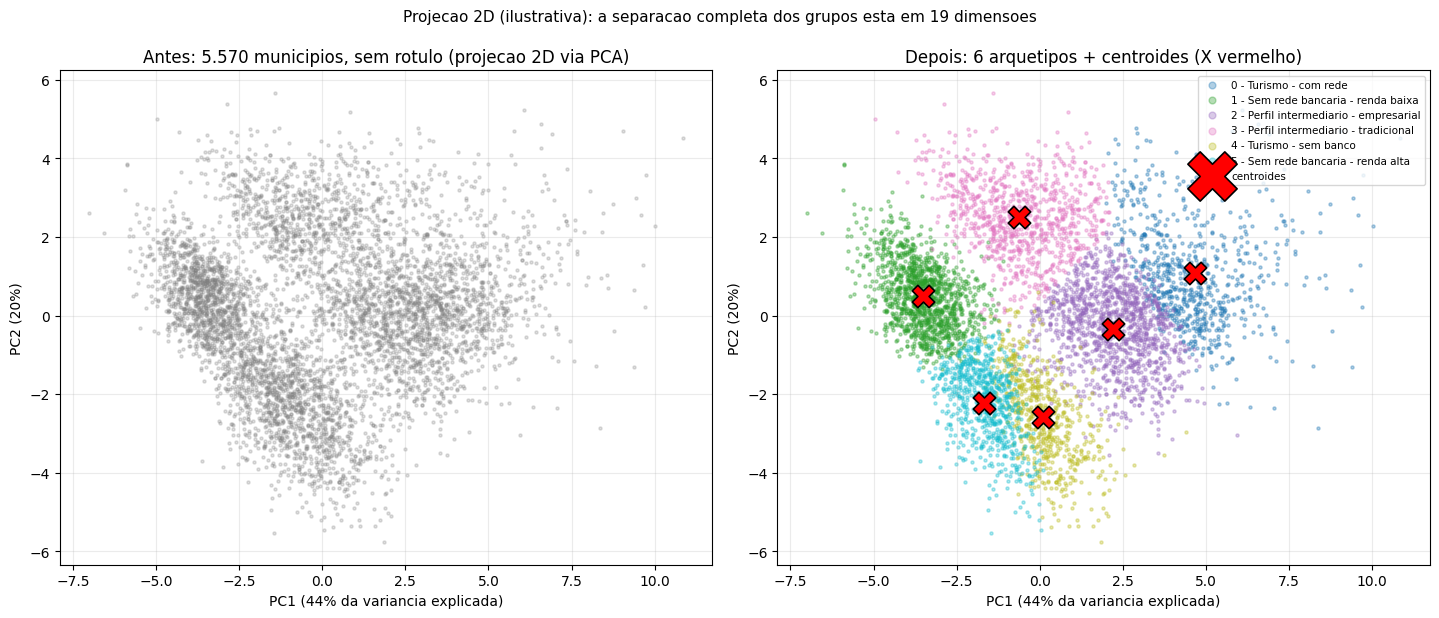

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_pad = StandardScaler().fit_transform(df_model[FEATURES_MODELO])
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_pad)
centers_2d = pca.transform(modelo_km.cluster_centers_)
var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], s=5, alpha=0.25, color="gray")
axes[0].set_title("Antes: 5.570 municipios, sem rotulo (projecao 2D via PCA)")

cores = plt.cm.tab10(np.linspace(0, 1, K_ESCOLHIDO))
for c in sorted(pd.unique(labels_km)):
    mascara = (labels_km.to_numpy() == c)
    axes[1].scatter(X_2d[mascara, 0], X_2d[mascara, 1], s=5, alpha=0.35,
                    color=cores[c], label=f"{c} - {nomes[c]}")
axes[1].scatter(centers_2d[:, 0], centers_2d[:, 1], marker="X", s=260,
                c="red", edgecolors="black", linewidths=1.2, zorder=5,
                label="centroides")
axes[1].set_title("Depois: 6 arquetipos + centroides (X vermelho)")
axes[1].legend(fontsize=7.5, markerscale=2.2, loc="upper right")

for ax in axes:
    ax.set_xlabel(f"PC1 ({var[0]:.0%} da variancia explicada)")
    ax.set_ylabel(f"PC2 ({var[1]:.0%})")
    ax.grid(alpha=0.25)
fig.suptitle("Projecao 2D (ilustrativa): a separacao completa dos grupos esta em 19 dimensoes",
             fontsize=11, y=0.99)
fig.tight_layout()
fig.savefig(FIGS / "01_scatter_pca_arquetipos.png", dpi=110)
plt.show()

## 5. Decisões registradas deste notebook

1. **Dataset** `modelagem.parquet` gravado na seção 3 (5.570 × 19 features + 2 alvos + referência IPB), **com `log1p` nas 14 colunas de cauda longa** — decisão metodológica registrada; percentuais ficaram lineares.
2. **K escolhido**: ver célula de decisão na seção 3 (métricas + legibilidade; iteração do grupo).
3. **Nomes dos arquétipos**: sugestões da seção 4 (perfis calculados nos **valores reais**, não no log)
4. GMM roda com o mesmo K e entrega a probabilidade de pertencimento (`prob_max_gmm`) — o município “83% arquétipo A, 17% B”.
5. **Achado**: `flag_tem_correspondente` é degenerada — **100% dos municípios têm ao menos 1 correspondente** (rede cobre o país inteiro). O alvo 2 da classificação sai da matriz e vira achado de relatório (notebook 02).